<a href="https://colab.research.google.com/github/coderdevil123/SPMOS_YOLOV11/blob/main/SPMOS_YOLOV11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.7/112.6 GB disk)


In [4]:
!unzip "/content/drive/MyDrive/SPMOS_YOLO/PKLot.v2i.yolov11.zip" -d "/content/datasets/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/datasets/train/labels/2013-03-16_07_55_02_jpg.rf.b9384ae89c1eb5734ec6879bfe4a390d.txt  
  inflating: /content/datasets/train/labels/2013-03-16_08_15_02_jpg.rf.5c8c2e5bc3390109633ff46f05531b46.txt  
  inflating: /content/datasets/train/labels/2013-03-16_08_20_02_jpg.rf.2a40bb0c0ddb21279cdf683bb91cc980.txt  
  inflating: /content/datasets/train/labels/2013-03-16_08_25_02_jpg.rf.0e7b384f6cd6a4803f126630904b0416.txt  
  inflating: /content/datasets/train/labels/2013-03-16_08_30_02_jpg.rf.3b75bb63818cbc795ca64928bcbd5c46.txt  
  inflating: /content/datasets/train/labels/2013-03-16_08_35_03_jpg.rf.bde30a14e645d3de4b13aa89baed6f3d.txt  
  inflating: /content/datasets/train/labels/2013-03-16_08_40_03_jpg.rf.5e090d53971326f6c7d6243096bfff43.txt  
  inflating: /content/datasets/train/labels/2013-03-16_08_45_03_jpg.rf.84feb1dac3e9daf137d259dca1a61ba1.txt  
  inflating: /content/datasets/train/labels/2013-03-16_09_00_03_jpg.r

In [8]:
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

results = model.train(
    data='/content/datasets/data.yaml',
    epochs=10,
    imgsz=320,                          # CHANGED: 640 -> 320 to make it harder
    batch=16,
    project='/content/drive/MyDrive/SPMOS_YOLO/results',
    name='parking_model_realistic'
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=parking_model_realistic, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

Displaying training graphs for: parking_model_realistic


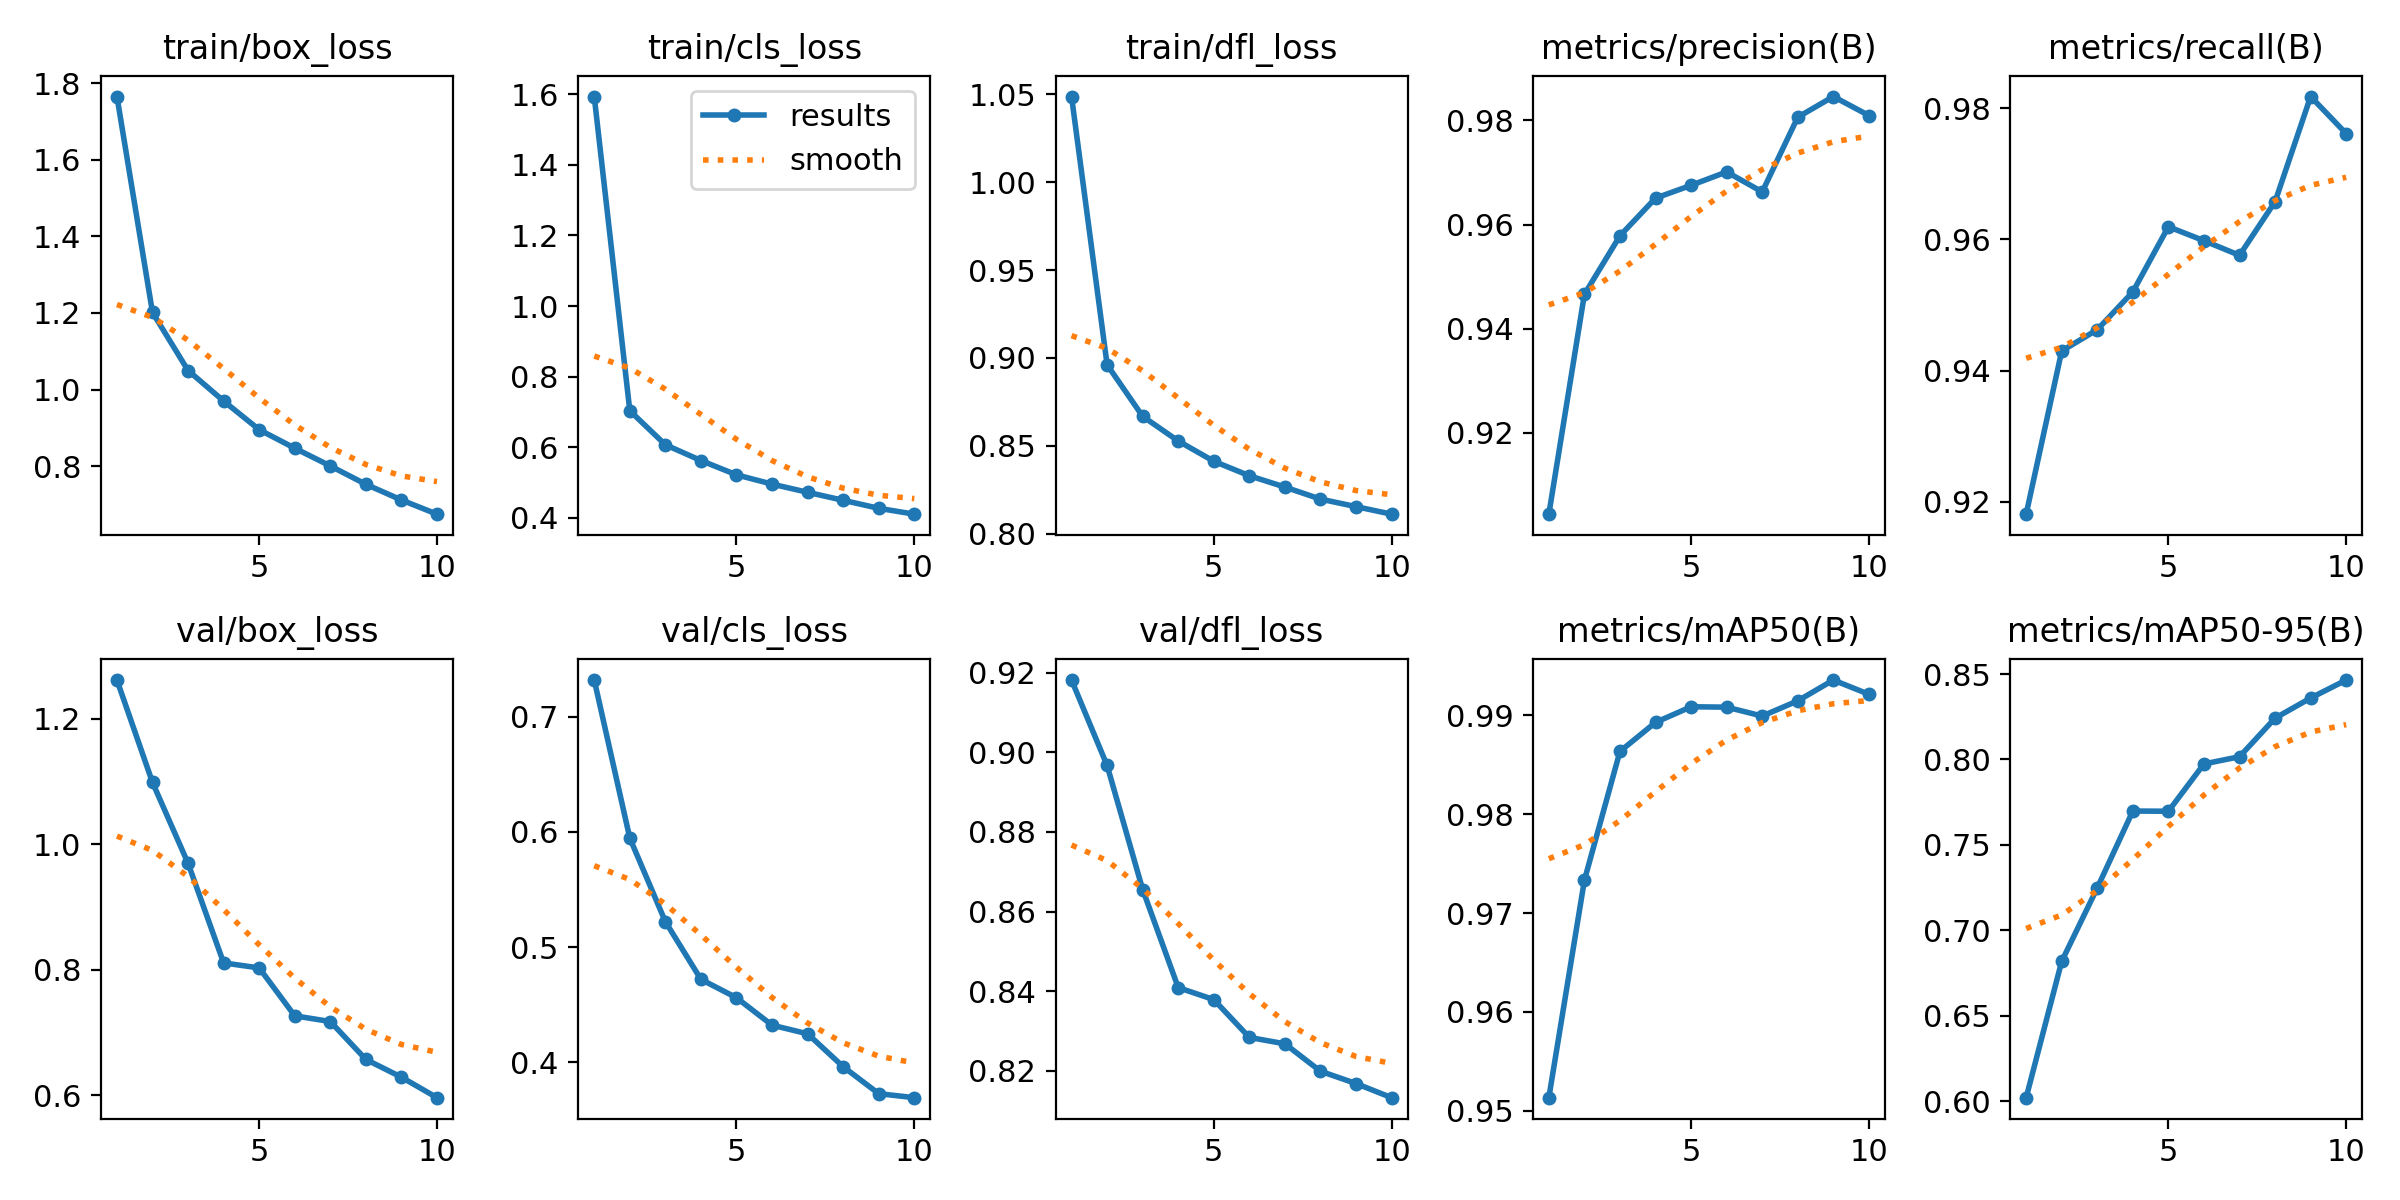

In [9]:
from IPython.display import Image, display

# Define the path to the folder of the model you want to view.
# Change 'parking_model_realistic' to 'parking_model_fast2' if you want the 92.9% model!
folder_name = 'parking_model_realistic'
graph_path = f'/content/drive/MyDrive/SPMOS_YOLO/results/{folder_name}/results.png'

print(f"Displaying training graphs for: {folder_name}")
display(Image(filename=graph_path))

Displaying Confusion Matrix:


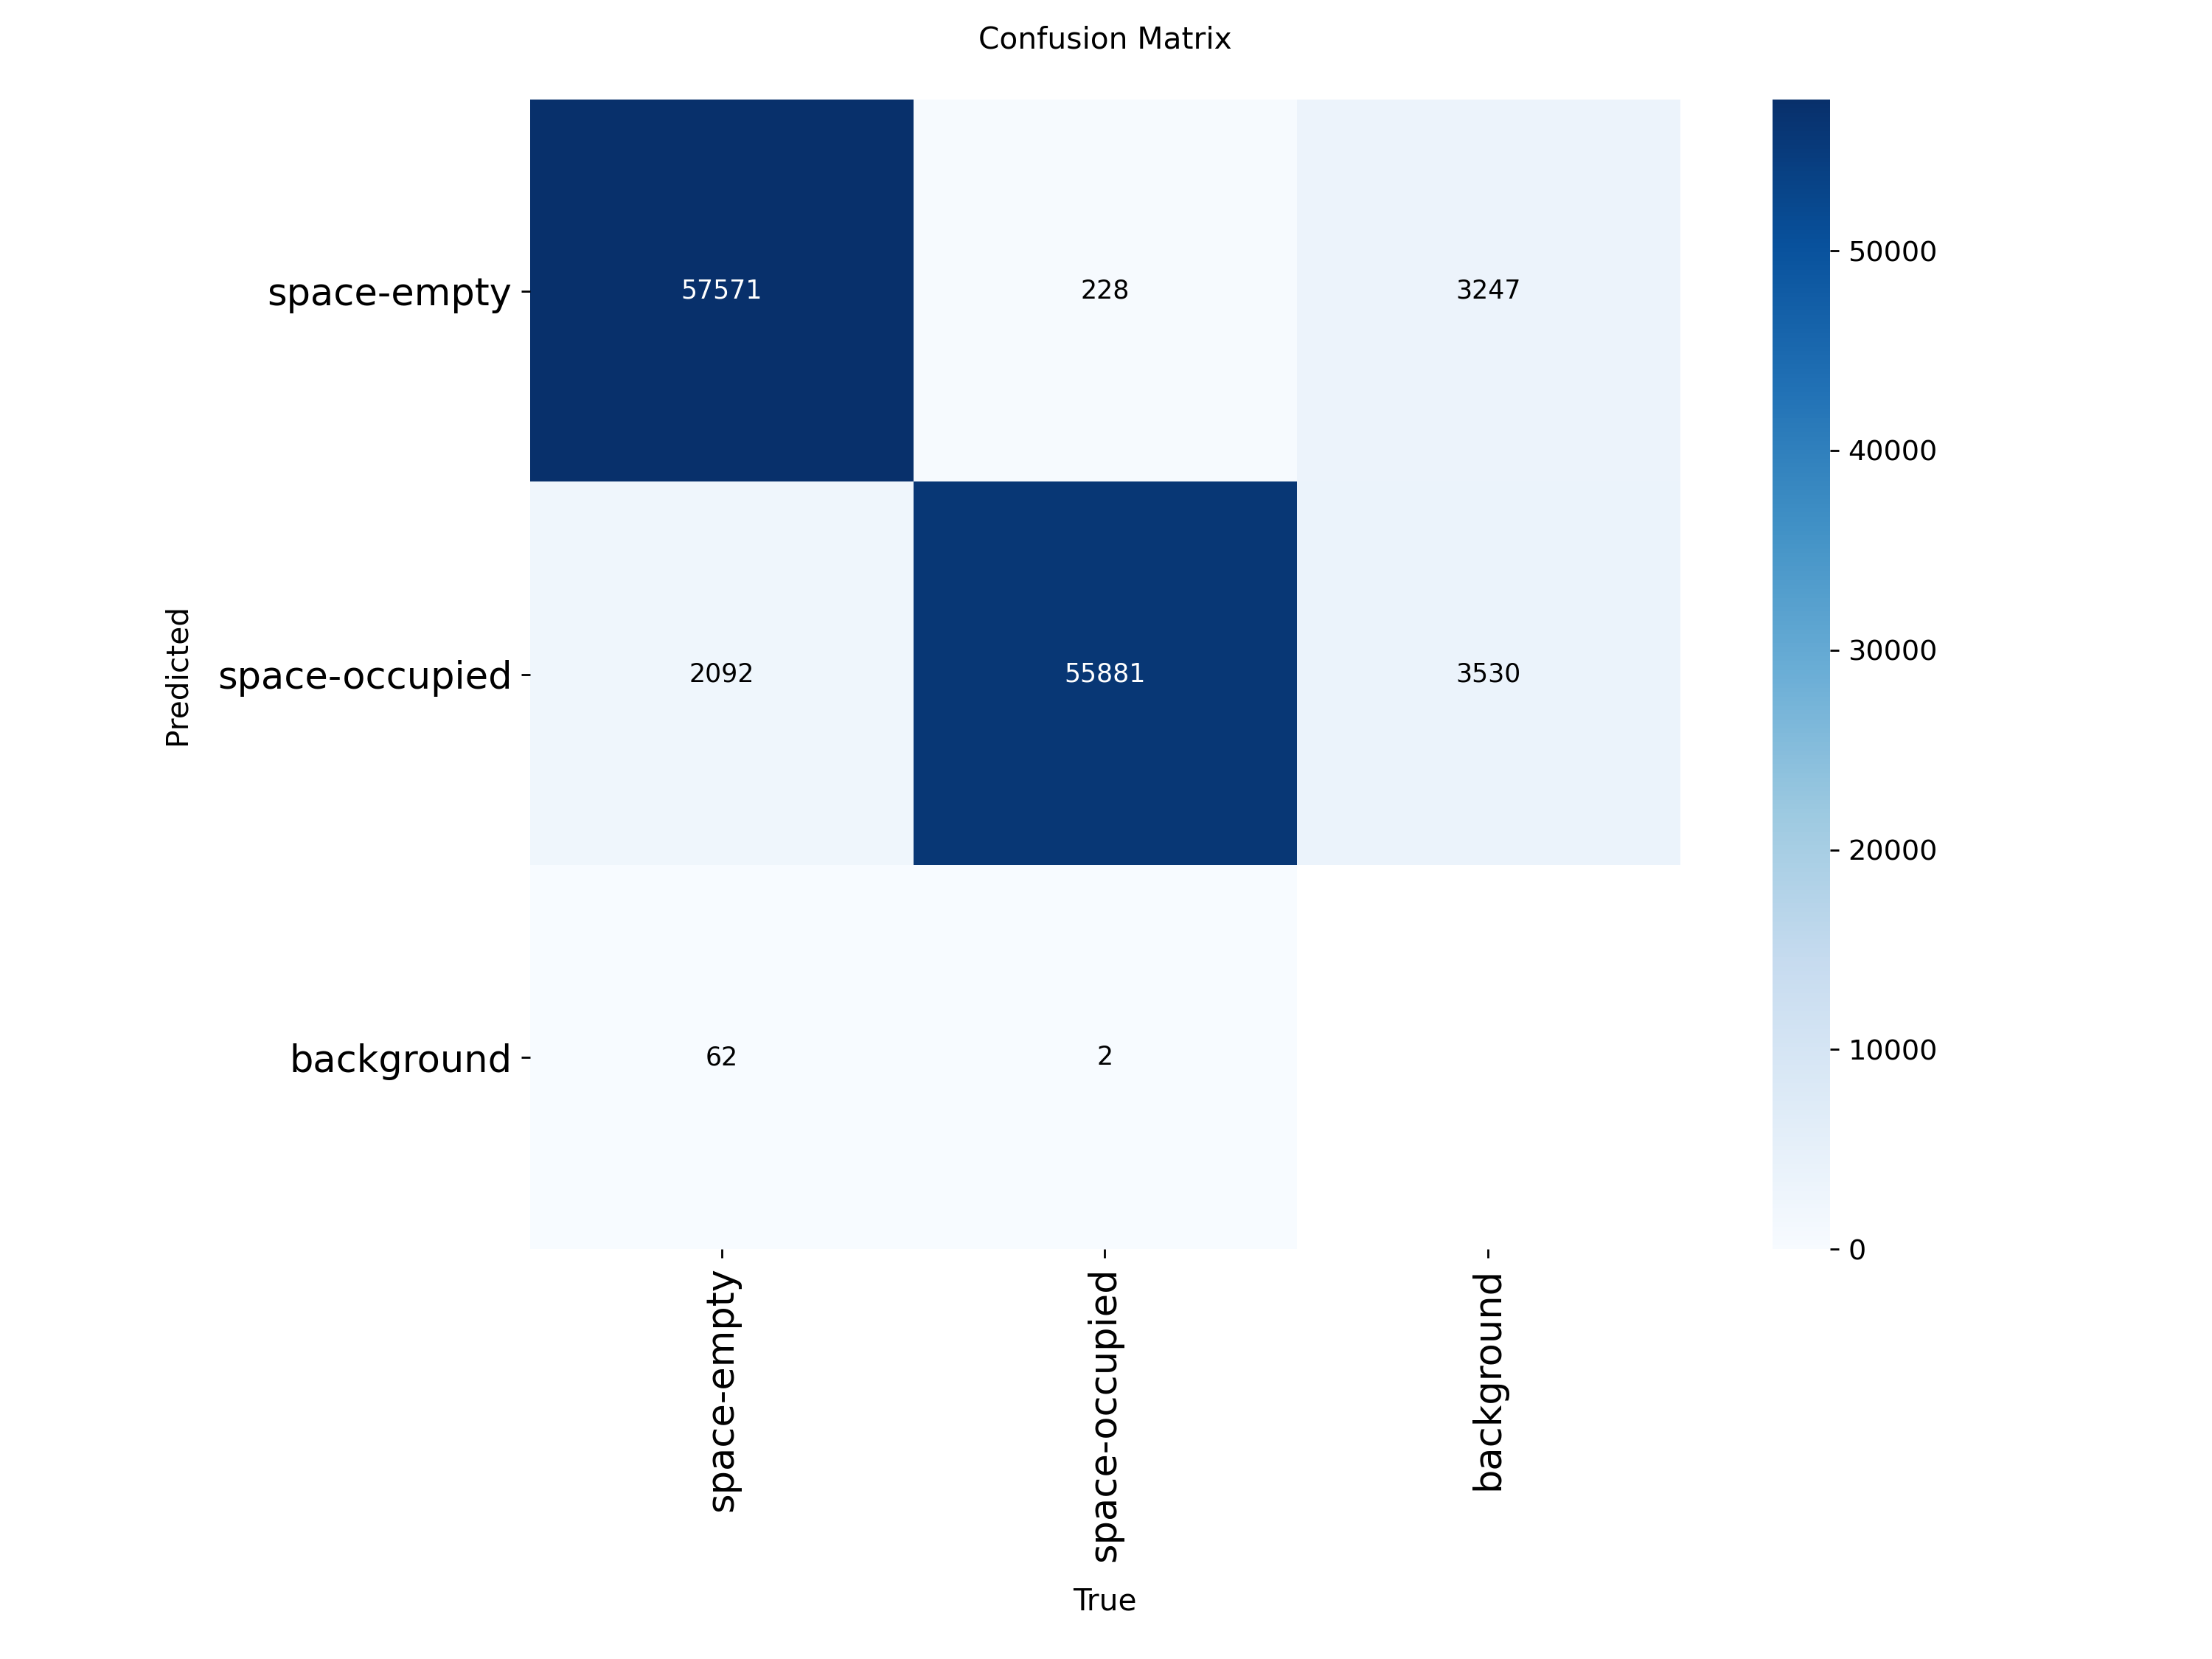

In [10]:
# Display the Confusion Matrix
confusion_matrix_path = f'/content/drive/MyDrive/SPMOS_YOLO/results/{folder_name}/confusion_matrix.png'

print("Displaying Confusion Matrix:")
display(Image(filename=confusion_matrix_path))

In [11]:
import pandas as pd

# Load the CSV file
csv_path = f'/content/drive/MyDrive/SPMOS_YOLO/results/{folder_name}/results.csv'
df = pd.read_csv(csv_path)

# Clean up the column names (YOLO adds empty spaces to them sometimes)
df.columns = df.columns.str.strip()

# Grab the final epoch's data
final_epoch = df.iloc[-1]

print("--- FINAL MODEL ACCURACY METRICS ---")
print(f"Overall Precision: {final_epoch['metrics/precision(B)'] * 100:.2f}%")
print(f"Overall Recall:    {final_epoch['metrics/recall(B)'] * 100:.2f}%")
print(f"mAP50:             {final_epoch['metrics/mAP50(B)'] * 100:.2f}%")
print(f"mAP50-95:          {final_epoch['metrics/mAP50-95(B)'] * 100:.2f}%")

--- FINAL MODEL ACCURACY METRICS ---
Overall Precision: 98.10%
Overall Recall:    97.61%
mAP50:             99.21%
mAP50-95:          84.65%


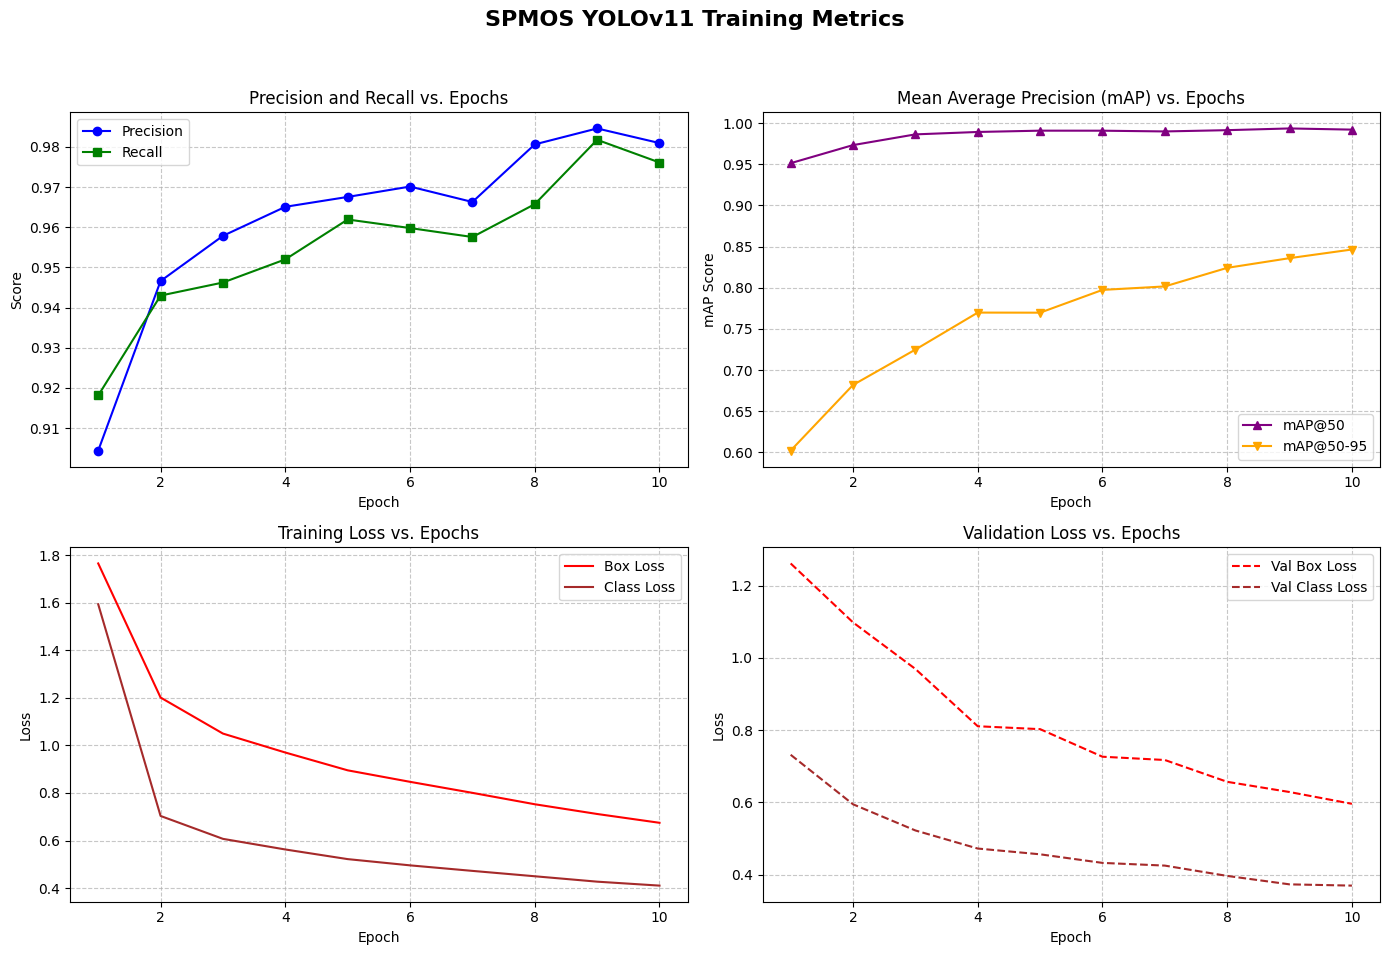

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define your folder name (change to 'parking_model_fast2' if you want the other model)
folder_name = 'parking_model_realistic'
csv_path = f'/content/drive/MyDrive/SPMOS_YOLO/results/{folder_name}/results.csv'

# 2. Load the data and clean up the column names
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip() # YOLO leaves annoying spaces in column names

# 3. Set up a 2x2 grid for our graphs
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SPMOS YOLOv11 Training Metrics', fontsize=16, fontweight='bold')

# --- GRAPH 1: Precision & Recall ---
axs[0, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='blue', marker='o')
axs[0, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='green', marker='s')
axs[0, 0].set_title('Precision and Recall vs. Epochs')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('Score')
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# --- GRAPH 2: Accuracy (mAP) ---
axs[0, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='purple', marker='^')
axs[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='orange', marker='v')
axs[0, 1].set_title('Mean Average Precision (mAP) vs. Epochs')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('mAP Score')
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# --- GRAPH 3: Training Loss ---
axs[1, 0].plot(df['epoch'], df['train/box_loss'], label='Box Loss', color='red')
axs[1, 0].plot(df['epoch'], df['train/cls_loss'], label='Class Loss', color='brown')
axs[1, 0].set_title('Training Loss vs. Epochs')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# --- GRAPH 4: Validation Loss ---
axs[1, 1].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='red', linestyle='--')
axs[1, 1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', color='brown', linestyle='--')
axs[1, 1].set_title('Validation Loss vs. Epochs')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout so nothing overlaps and show the plot!
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()